In [2]:
import numpy as np

import stim

from tools.surface_code import generate_steane_circuit, generate_surface_code_circuit
from tools.error_models import add_noise, construct_basic_noise_model, construct_circuit_noise_model, construct_bit_flip_model 
from tools.analysis import generate_log_error_rates,count_logical_errors_using_MWPM, count_logical_errors_using_ML,  gen_error_model_count_logical_error_MWPM, gen_multi_rep_count_logical_error_MWPM
from tools.helper import split_and_pauli_frame_track 

In [7]:
import tools.graphics as graphic 
from importlib import reload
reload(graphic)

<module 'tools.graphics' from '/home/leo/Documents/MasterArbeit/code/new_start/tools/graphics.py'>

In [ ]:
#ML (Basic Noise)
distances = [3,5]
reps = 1
noise_set = np.logspace(-2,-0.9, num=10)
# ML
num_shots = 10_000
count_logical_func = count_logical_errors_using_ML

steane_circuits = [generate_steane_circuit(d,rounds=reps) for d in distances]


log_error_rates_ML, y_errs_ML = generate_log_error_rates(
    steane_circuits,
    construct_bit_flip_model,
    count_log_error_fct=count_logical_func,
    distances= distances,
    noise_set= noise_set,
    num_shots= num_shots,
)

/home/leo/Documents/MasterArbeit/code/new_start/tools/aron_ml.py:56: RuntimeWarning: invalid value encountered in sqrt
  log_gamma=log_gamma+np.log(np.sqrt(np.linalg.det(M+A)))
/home/leo/Documents/MasterArbeit/code/new_start/tools/aron_ml.py:102: RuntimeWarning: invalid value encountered in scalar power
  return 1/2*log_gamma-1/2*np.log(2)+np.log(np.linalg.det(M+M0)**(1/4))


In [ ]:
# MWMP (Basic Noise)
distances = [3,5]
reps = 1
noise_set = np.logspace(-2,-0.9, num=10)
# MWPM
num_shots = 100_000
count_logical_func = gen_error_model_count_logical_error_MWPM("bit_flip")

steane_circuits = [generate_steane_circuit(d,rounds=reps) for d in distances]


log_error_rates_MWPM, y_errs_MWPM = generate_log_error_rates(
    steane_circuits,
    construct_bit_flip_model,
    count_log_error_fct=count_logical_func,
    distances= distances,
    noise_set= noise_set,
    num_shots= num_shots,
)

<Figure size 640x480 with 0 Axes>

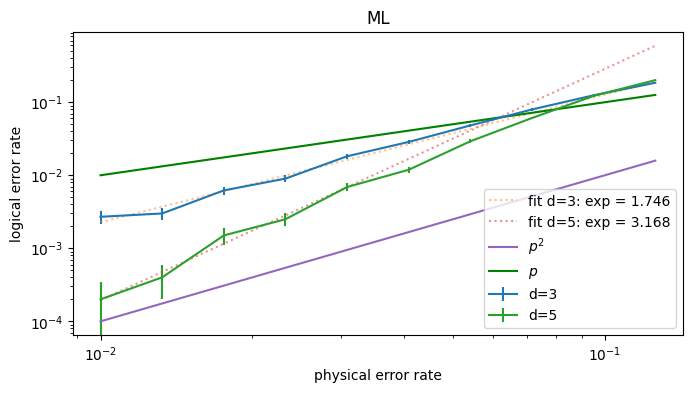

<Figure size 640x480 with 0 Axes>

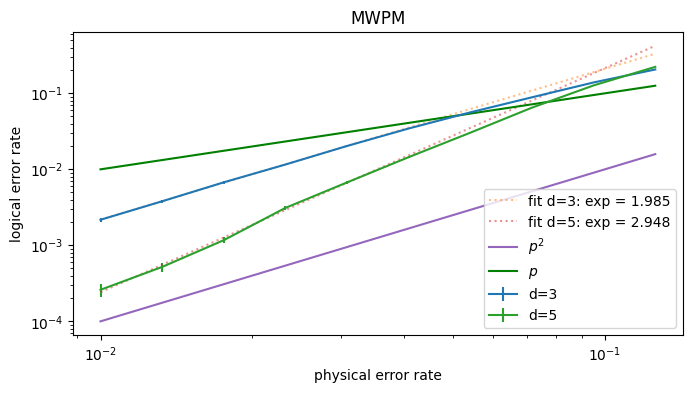

In [8]:
graphic.plot_diff_noise_level(
        log_error_rates_ML,
        y_errs_ML,
        distances,
        noise_set,
        fit_slopes = True,
        reference_lines = True,
        title="ML"
    ) 
graphic.plot_diff_noise_level(
        log_error_rates_MWPM,
        y_errs_MWPM,
        distances,
        noise_set,
        fit_slopes = True,
        reference_lines = True,
        title="MWPM"
    ) 